In [ ]:
import marimo as mo

> **Generated file.** This notebook is exported from its marimo source
> src/pipelines/04_eda_annot_gt_cycle/04_ukdale_all_device_eda.py.
> Edit the source and re-export; do not edit the exported notebook by hand.

# Every device, every house: metadata verification + extended curation

The focus tranche (washing machine, dishwasher, kettle, microwave,
fridge - 03_ukdale_houses_gt_cycle_eda) covers the canonical NILM
targets only. This notebook widens the aperture to **all 103 gold
channels**: every device gets a metadata row (suggested class +
generic-threshold episode stats) and every episodic non-focus device
gets the same visualize-then-verify treatment the focus devices got.

Class taxonomy (name-based prior, verified below by figures):
**program** (automatic multi-phase), **burst** (short stereotyped
manual), **duty** (thermostatic/periodic), **manual** (long
user-controlled sessions), **heating**, **always_on** (network /
standby draw), **electronics** (entertainment/computing),
**lighting**. Non-focus rows are metadata, not cycle GT: their
episode stats come from a generic 20 W threshold with burst-rule
shaping, and the in_focus column separates them from the curated
focus devices. All numbers provisional; nothing is a gate.

In [ ]:
# Headless rendering + shared baseline lib (same pattern as 01/03).
import sys
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
_here = Path(__file__).resolve()
sys.path.insert(0, str(_here.parents[2] / "experiments" / "00_baseline"))
import baseline_lib as bl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
# --- Notebook parameters (provisional, stated up front) ---------------
cfg = {
    "dataset": "ukdale",
    "houses": ("house_1", "house_2", "house_3", "house_4", "house_5"),
    "focus": ("washing_machine", "dishwasher", "kettle", "microwave", "fridge"),
    "generic_thr_w": 20.0,  # all-device metadata threshold (02_build_rule_profiles)
    "generic_dwell_s": 30.0,
    "generic_merge_s": 60.0,
    # candidate-generation rule per suggested class (review sheets only;
    # stored marks are hand-drawn spans, independent of these rules)
    "cand_rule": {
        "program": (600.0, 600.0),  # same shape as the focus program rule
        "manual": (30.0, 300.0),  # group burner/pause fragments into a session
        "burst": (30.0, 60.0),  # raw episodes, same shape as the burst rule
    },
    "cand_min_cal": 20,  # need >= 20 pre-split episodes to curate 20 marks
    "sheet_top": 30,
    "sheet_pad_s": 1200.0,
    "seed": 3,
}

In [ ]:
mo.md(
    "## Parameters used in this EDA\n\n"
    + bl.md_table(["parameter", "value"], [[k, v] for k, v in cfg.items()])
)

## Parameters used in this EDA

| parameter | value |
|---|---|
| dataset | ukdale |
| houses | ('house_1', 'house_2', 'house_3', 'house_4', 'house_5') |
| focus | ('washing_machine', 'dishwasher', 'kettle', 'microwave', 'fridge') |
| generic_thr_w | 20.0 |
| generic_dwell_s | 30.0 |
| generic_merge_s | 60.0 |
| cand_rule | {'program': (600.0, 600.0), 'manual': (30.0, 300.0), 'burst': (30.0, 60.0)} |
| cand_min_cal | 20 |
| sheet_top | 30 |
| sheet_pad_s | 1200.0 |
| seed | 3 |

In [ ]:
# --- Load the all-device profile store (computation) -------------------
# Written by 02_build_rule_profiles.py (single writer); displayed here.
_profiles_frames = []
_splits_frames = []
for _h in cfg["houses"]:
    _profiles_frames.append(
        pd.read_csv(bl.gold_annot_file(cfg["dataset"], _h, "device_profile"))
    )
    _splits_frames.append(pd.read_csv(bl.gold_annot_file(cfg["dataset"], _h, "splits")))
profiles_df = pd.concat(_profiles_frames, ignore_index=True)
splits_df = pd.concat(_splits_frames, ignore_index=True)

In [ ]:
# presentation: class census + full metadata table
_census = profiles_df.groupby(["house", "in_focus"]).size().unstack(fill_value=0)
_cen_rows = [
    [h, int(r.get(True, 0)), int(r.get(False, 0)), int(r.sum())]
    for h, r in _census.iterrows()
]
_cls_rows = [
    [c, int(n)]
    for c, n in profiles_df[~profiles_df["in_focus"]]["class"]
    .value_counts()
    .items()
]
_meta_rows = [
    [
        r["house"].replace("house_", "h"),
        r["device"],
        str(r["class"]),
        f"{r['thr_used_w']:.0f}",
        f"{r['n_cycles_cal']:,}",
        f"{r['dur_p50_min']:.1f}" if r["dur_p50_min"] == r["dur_p50_min"] else "-",
        f"{r['energy_p50_wh']:.0f}" if r["energy_p50_wh"] == r["energy_p50_wh"] else "-",
        f"{r['on_power_p50_w']:.0f}" if r["on_power_p50_w"] == r["on_power_p50_w"] else "-",
    ]
    for r in profiles_df.to_dict("records")
]
mo.md(
    "## The all-device metadata store\n\n"
    f"**{len(profiles_df)} device rows** across 5 houses "
    f"({int(profiles_df['in_focus'].sum())} in-focus, "
    f"{int((~profiles_df['in_focus']).sum())} metadata-only). "
    "Class census of the non-focus devices:\n\n"
    + bl.md_table(["class", "devices"], _cls_rows)
    + "\n\nDevices per house:\n\n"
    + bl.md_table(["house", "in focus", "non-focus", "total"], _cen_rows)
    + "\n\n**Full metadata table** (every gold channel; thr is the "
    "threshold behind the episode columns - gold-derived for focus "
    "devices, generic 20 W for the rest; dur/energy p50 are per "
    "episode; on-power p50 is the median draw above threshold):\n\n"
    + bl.md_table(
        [
            "house",
            "device",
            "class",
            "thr (W)",
            "episodes (cal)",
            "dur p50 (min)",
            "energy p50 (Wh)",
            "on-power p50 (W)",
        ],
        _meta_rows,
    )
    + "\n\nAlready visible from the numbers: always_on devices show "
    "hundreds of micro-episodes (1 min, <1 Wh) - standby jitter around "
    "the generic threshold, not usage; their episode stats carry no "
    "usage meaning. house_1 gas_oven draws ~46 W p50 - igniter/fan "
    "electronics only, no cooking signal on this channel."
)

## The all-device metadata store

**103 device rows** across 5 houses (19 in-focus, 84 metadata-only). Class census of the non-focus devices:

| class | devices |
|---|---|
| electronics | 35 |
| lighting | 15 |
| manual | 11 |
| always_on | 9 |
| burst | 7 |
| heating | 3 |
| program | 3 |
| duty | 1 |

Devices per house:

| house | in focus | non-focus | total |
|---|---|---|---|
| house_1 | 5 | 47 | 52 |
| house_2 | 5 | 13 | 18 |
| house_3 | 1 | 3 | 4 |
| house_4 | 3 | 2 | 5 |
| house_5 | 5 | 19 | 24 |

**Full metadata table** (every gold channel; thr is the threshold behind the episode columns - gold-derived for focus devices, generic 20 W for the rest; dur/energy p50 are per episode; on-power p50 is the median draw above threshold):

| house | device | class | thr (W) | episodes (cal) | dur p50 (min) | energy p50 (Wh) | on-power p50 (W) |
|---|---|---|---|---|---|---|---|
| h1 | washing_machine | program | 90 | 199 | 91.0 | 730 | 256 |
| h1 | dishwasher | program | 60 | 94 | 85.8 | 1504 | 122 |
| h1 | kettle | burst | 1173 | 1,138 | 1.8 | 74 | 2348 |
| h1 | microwave | burst | 762 | 775 | 1.0 | 24 | 1553 |
| h1 | fridge | duty | 44 | 7,094 | 24.6 | 40 | 89 |
| h1 | adsl_router | always_on | 20 | 0 | 0.8 | 0 | 21 |
| h1 | amp_livingroom | electronics | 20 | 431 | 106.6 | 41 | 23 |
| h1 | baby_monitor_tx | electronics | 20 | 0 | - | - | 550 |
| h1 | battery_charger | electronics | 20 | 48 | 3.3 | 1 | 27 |
| h1 | bedroom_chargers | electronics | 20 | 0 | 1.6 | 0 | 36 |
| h1 | bedroom_d_lamp | lighting | 20 | 16 | 19.3 | 10 | 26 |
| h1 | bedroom_ds_lamp | lighting | 20 | 115 | 7.3 | 3 | 25 |
| h1 | boiler | heating | 20 | 895 | 32.7 | 36 | 59 |
| h1 | breadmaker | program | 20 | 417 | 2.1 | 4 | 558 |
| h1 | childs_ds_lamp | lighting | 20 | 10 | 12.5 | 9 | 43 |
| h1 | childs_table_lamp | lighting | 20 | 0 | - | - | 654 |
| h1 | coffee_machine | program | 20 | 6 | 20.4 | 82 | 52 |
| h1 | dab_radio_livingroom | electronics | 20 | 0 | - | - | 429 |
| h1 | data_logger_pc | always_on | 20 | 8 | 0.8 | 0 | 22 |
| h1 | gas_oven | manual | 20 | 216 | 22.9 | 18 | 46 |
| h1 | gige_usbhub | always_on | 20 | 0 | 1551.1 | 1125 | 39 |
| h1 | hair_dryer | burst | 20 | 133 | 1.6 | 29 | 1153 |
| h1 | hifi_office | electronics | 20 | 41 | 2.4 | 0 | 23 |
| h1 | hoover | manual | 20 | 149 | 4.6 | 129 | 1912 |
| h1 | htpc | electronics | 20 | 743 | 70.1 | 81 | 69 |
| h1 | ipad_charger | electronics | 20 | 0 | - | - | 498 |
| h1 | iron | manual | 20 | 18 | 2.2 | 24 | 1791 |
| h1 | kitchen_dt_lamp | lighting | 20 | 48 | 33.4 | 23 | 41 |
| h1 | kitchen_lamp2 | lighting | 20 | 584 | 1.9 | 0 | 21 |
| h1 | kitchen_lights | lighting | 20 | 2,243 | 7.2 | 18 | 134 |
| h1 | kitchen_phone_stereo | electronics | 20 | 1 | 1.8 | 0 | 21 |
| h1 | kitchen_radio | electronics | 20 | 1 | 0.6 | 2 | 194 |
| h1 | laptop | electronics | 20 | 1,963 | 3.3 | 1 | 26 |
| h1 | lcd_office | electronics | 20 | 511 | 29.6 | 26 | 51 |
| h1 | led_printer | electronics | 20 | 0 | 1.1 | 6 | 542 |
| h1 | lighting_circuit | lighting | 20 | 1,461 | 6.5 | 7 | 81 |
| h1 | livingroom_lamp_tv | lighting | 20 | 0 | 0.9 | 0 | 25 |
| h1 | livingroom_s_lamp | lighting | 20 | 0 | 0.9 | 0 | 1043 |
| h1 | livingroom_s_lamp2 | lighting | 20 | 0 | - | - | 21 |
| h1 | office_fan | electronics | 20 | 29 | 44.8 | 25 | 32 |
| h1 | office_lamp1 | lighting | 20 | 0 | 0.7 | 0 | 28 |
| h1 | office_lamp2 | lighting | 20 | 0 | - | - | 23 |
| h1 | office_lamp3 | lighting | 20 | 0 | - | - | 466 |
| h1 | office_pc | electronics | 20 | 31 | 86.5 | 257 | 173 |
| h1 | samsung_charger | electronics | 20 | 0 | - | - | 525 |
| h1 | solar_thermal_pump | duty | 20 | 3,083 | 3.0 | 3 | 48 |
| h1 | soldering_iron | manual | 20 | 8 | 21.5 | 8 | 58 |
| h1 | straighteners | burst | 20 | 79 | 6.2 | 15 | 115 |
| h1 | subwoofer_livingroom | electronics | 20 | 7 | 1.2 | 0 | 27 |
| h1 | toaster | burst | 20 | 808 | 3.1 | 83 | 1576 |
| h1 | tv | electronics | 20 | 474 | 92.3 | 165 | 103 |
| h1 | utilityrm_lamp | lighting | 20 | 10 | 1.6 | 1 | 44 |
| h2 | washing_machine | program | 81 | 36 | 39.5 | 404 | 259 |
| h2 | dishwasher | program | 90 | 66 | 47.2 | 1112 | 1984 |
| h2 | kettle | burst | 1477 | 522 | 2.8 | 143 | 2954 |
| h2 | microwave | burst | 500 | 261 | 1.8 | 37 | 1311 |
| h2 | fridge | duty | 40 | 2,331 | 15.2 | 23 | 88 |
| h2 | cooker | manual | 20 | 1 | 3.2 | 2 | 26 |
| h2 | laptop | electronics | 20 | 5,240 | 1.7 | 0 | 30 |
| h2 | laptop2 | electronics | 20 | 285 | 12.1 | 5 | 26 |
| h2 | modem | always_on | 20 | 0 | - | - | 137 |
| h2 | monitor | electronics | 20 | 473 | 137.9 | 140 | 61 |
| h2 | playstation | electronics | 20 | 3 | 7.6 | 7 | 32 |
| h2 | rice_cooker | program | 20 | 38 | 28.3 | 140 | 397 |
| h2 | router | always_on | 20 | 679 | 1.1 | 0 | 23 |
| h2 | running_machine | manual | 20 | 43 | 16.4 | 80 | 283 |
| h2 | server | always_on | 20 | 1,032 | 1.1 | 0 | 27 |
| h2 | server_hdd | always_on | 20 | 0 | - | - | 22 |
| h2 | speakers | electronics | 20 | 2 | 0.5 | 0 | 22 |
| h2 | toaster | burst | 20 | 25 | 1.7 | 28 | 968 |
| h3 | kettle | burst | 1475 | 34 | 1.8 | 94 | 2952 |
| h3 | electric_heater | heating | 20 | 10 | 51.2 | 1768 | 1137 |
| h3 | laptop | electronics | 20 | 625 | 1.6 | 0 | 33 |
| h3 | projector | electronics | 20 | 23 | 117.6 | 438 | 237 |
| h4 | kettle | burst | 1083 | 502 | 2.0 | 80 | 2174 |
| h4 | microwave | burst | 90 | 0 | - | - | - |
| h4 | fridge | duty | 46 | 3,907 | 17.2 | 27 | 91 |
| h4 | gas_boiler | heating | 20 | 443 | 41.2 | 68 | 104 |
| h4 | tv_dvd_digibox_lamp | electronics | 20 | 292 | 6.0 | 4 | 55 |
| h5 | washing_machine | program | 50 | 85 | 75.3 | 792 | 474 |
| h5 | dishwasher | program | 48 | 38 | 89.5 | 1104 | 97 |
| h5 | kettle | burst | 1445 | 186 | 1.7 | 86 | 2891 |
| h5 | microwave | burst | 25 | 0 | - | - | - |
| h5 | fridge | duty | 54 | 2,352 | 21.9 | 40 | 108 |
| h5 | 24_inch_lcd | electronics | 20 | 307 | 43.9 | 19 | 27 |
| h5 | 24_inch_lcd_bedroom | electronics | 20 | 69 | 62.8 | 94 | 88 |
| h5 | atom_pc | electronics | 20 | 1 | 100674.1 | 40260 | 24 |
| h5 | core2_server | always_on | 20 | 1 | 155822.3 | 212494 | 81 |
| h5 | electric_hob | manual | 20 | 214 | 5.0 | 38 | 1599 |
| h5 | hairdryer | burst | 20 | 44 | 4.7 | 82 | 1096 |
| h5 | home_theatre_amp | electronics | 20 | 4 | 29493.8 | 14094 | 25 |
| h5 | i7_desktop | electronics | 20 | 55 | 652.5 | 915 | 85 |
| h5 | nespresso_pixie | burst | 20 | 125 | 2.0 | 22 | 776 |
| h5 | network_attached_storage | always_on | 20 | 241 | 1.2 | 0 | 21 |
| h5 | oven | manual | 20 | 93 | 26.5 | 673 | 2105 |
| h5 | primary_tv | electronics | 20 | 173 | 65.5 | 73 | 68 |
| h5 | ps4 | electronics | 20 | 0 | - | - | - |
| h5 | sky_hd_box | electronics | 20 | 176 | 1.0 | 0 | 21 |
| h5 | steam_iron | manual | 20 | 7 | 8.1 | 171 | 2232 |
| h5 | stereo_speakers_bedroom | electronics | 20 | 1 | 1.9 | 3 | 105 |
| h5 | toaster | burst | 20 | 23 | 2.0 | 39 | 1086 |
| h5 | treadmill | manual | 20 | 55 | 16.9 | 128 | 410 |
| h5 | vacuum_cleaner | manual | 20 | 15 | 1.6 | 47 | 1918 |

Already visible from the numbers: always_on devices show hundreds of micro-episodes (1 min, <1 Wh) - standby jitter around the generic threshold, not usage; their episode stats carry no usage meaning. house_1 gas_oven draws ~46 W p50 - igniter/fan electronics only, no cooking signal on this channel.

In [ ]:
# --- Class palette (computation) -----------------------------------------
cls_color = {
    "program": "#1f77b4",
    "burst": "#d95f02",
    "duty": "#2ca02c",
    "manual": "#9467bd",
    "heating": "#8c564b",
    "always_on": "#7f7f7f",
    "electronics": "#e377c2",
    "lighting": "#bcbd22",
    "misc": "#17becf",
}

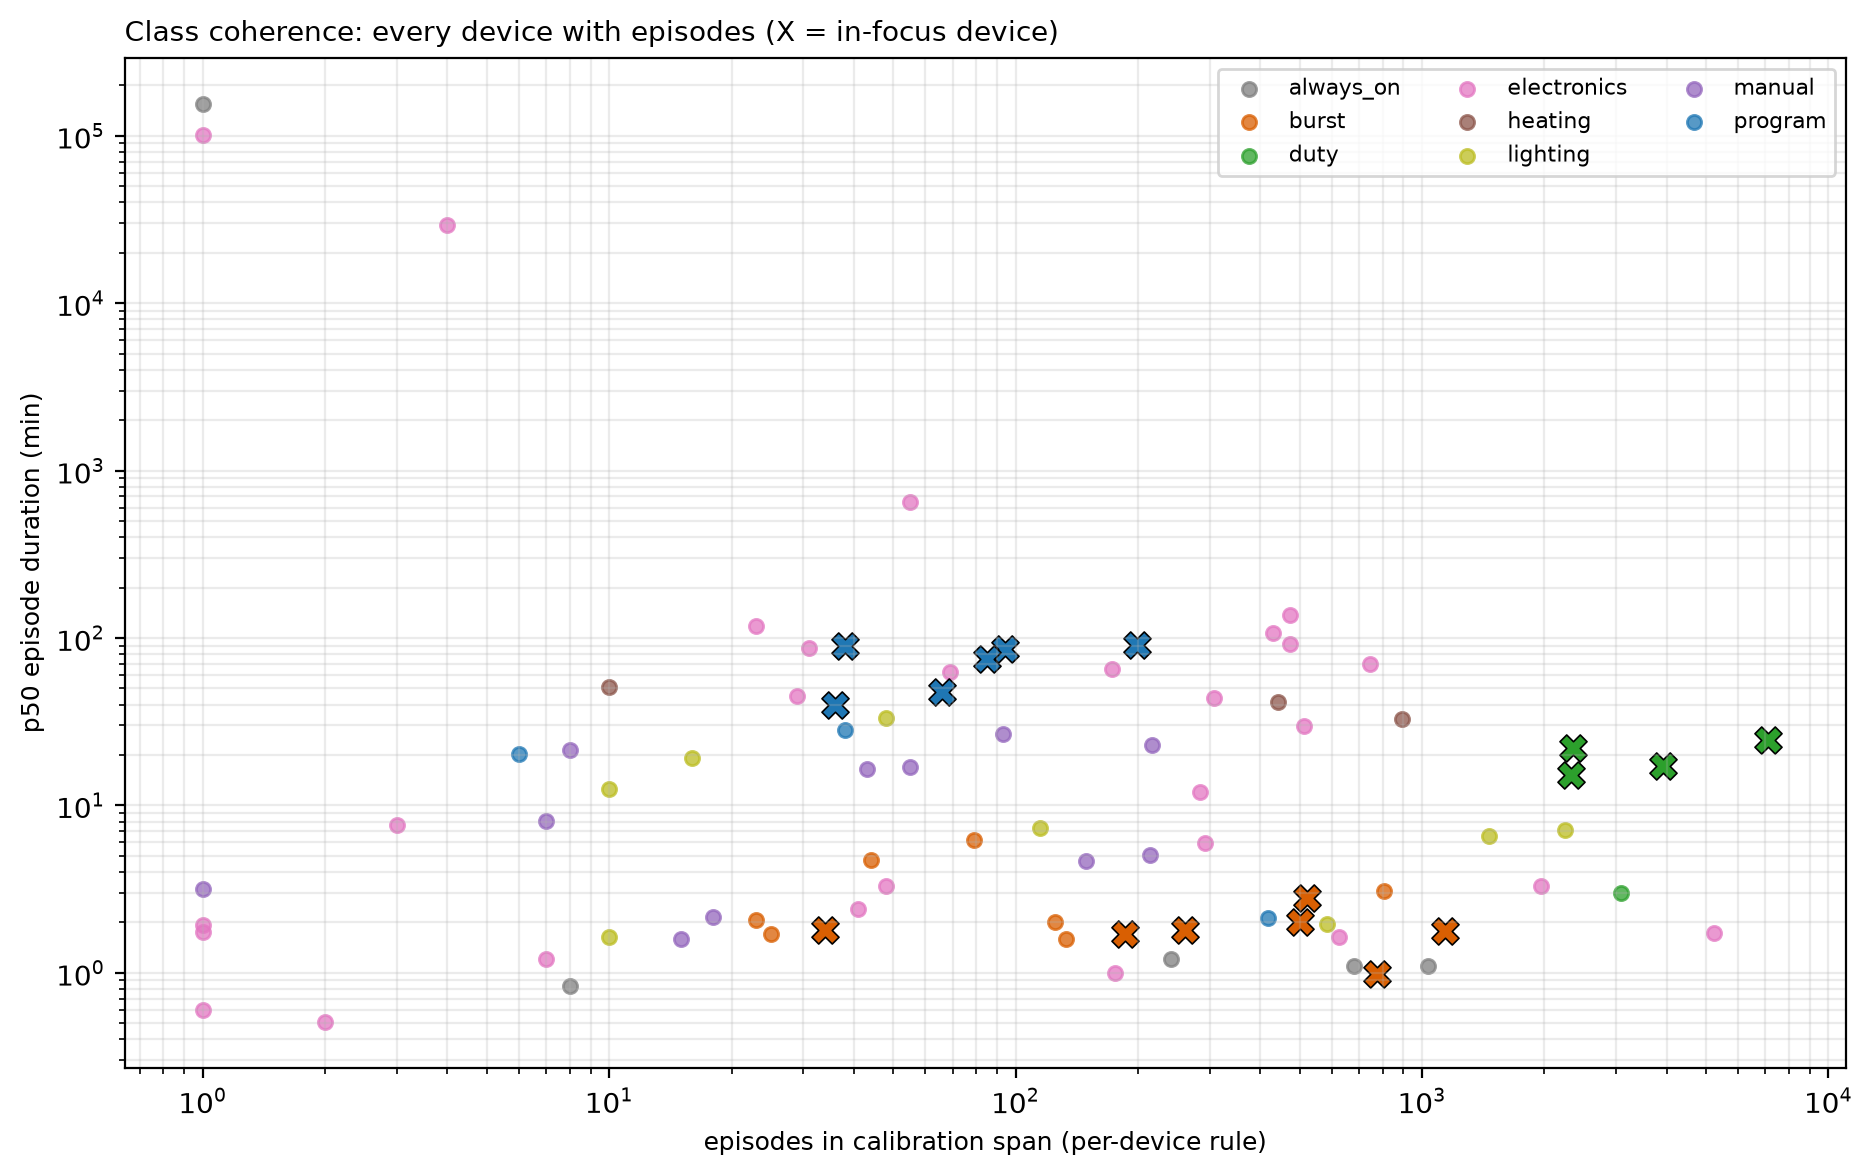

In [ ]:
# --- Class-verification scatter (fig) ------------------------------------
# Episodes (cal span, log) vs p50 duration (log) colored by class; the
# in-focus devices plot as X markers. Coherent classes cluster; a point
# far from its class neighbours is a labeling candidate.
_d = profiles_df[profiles_df["n_cycles_cal"] > 0]
fig_scatter, ax = plt.subplots(figsize=(9.5, 6.0))
for _c, _g in _d.groupby("class"):
    _foc = _g[_g["in_focus"]]
    _non = _g[~_g["in_focus"]]
    if len(_non):
        ax.scatter(
            _non["n_cycles_cal"],
            _non["dur_p50_min"],
            s=26,
            alpha=0.75,
            color=cls_color.get(_c, "#333333"),
            label=_c,
        )
    if len(_foc):
        ax.scatter(
            _foc["n_cycles_cal"],
            _foc["dur_p50_min"],
            s=95,
            marker="X",
            edgecolors="black",
            linewidths=0.6,
            color=cls_color.get(_c, "#333333"),
        )
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("episodes in calibration span (per-device rule)", fontsize=9)
ax.set_ylabel("p50 episode duration (min)", fontsize=9)
ax.set_title(
    "Class coherence: every device with episodes (X = in-focus device)",
    fontsize=10,
    loc="left",
)
ax.legend(fontsize=8, ncol=3, loc="best")
ax.grid(alpha=0.25, which="both")
fig_scatter.tight_layout()
fig_scatter  # noqa: B018  (render figure as cell output)

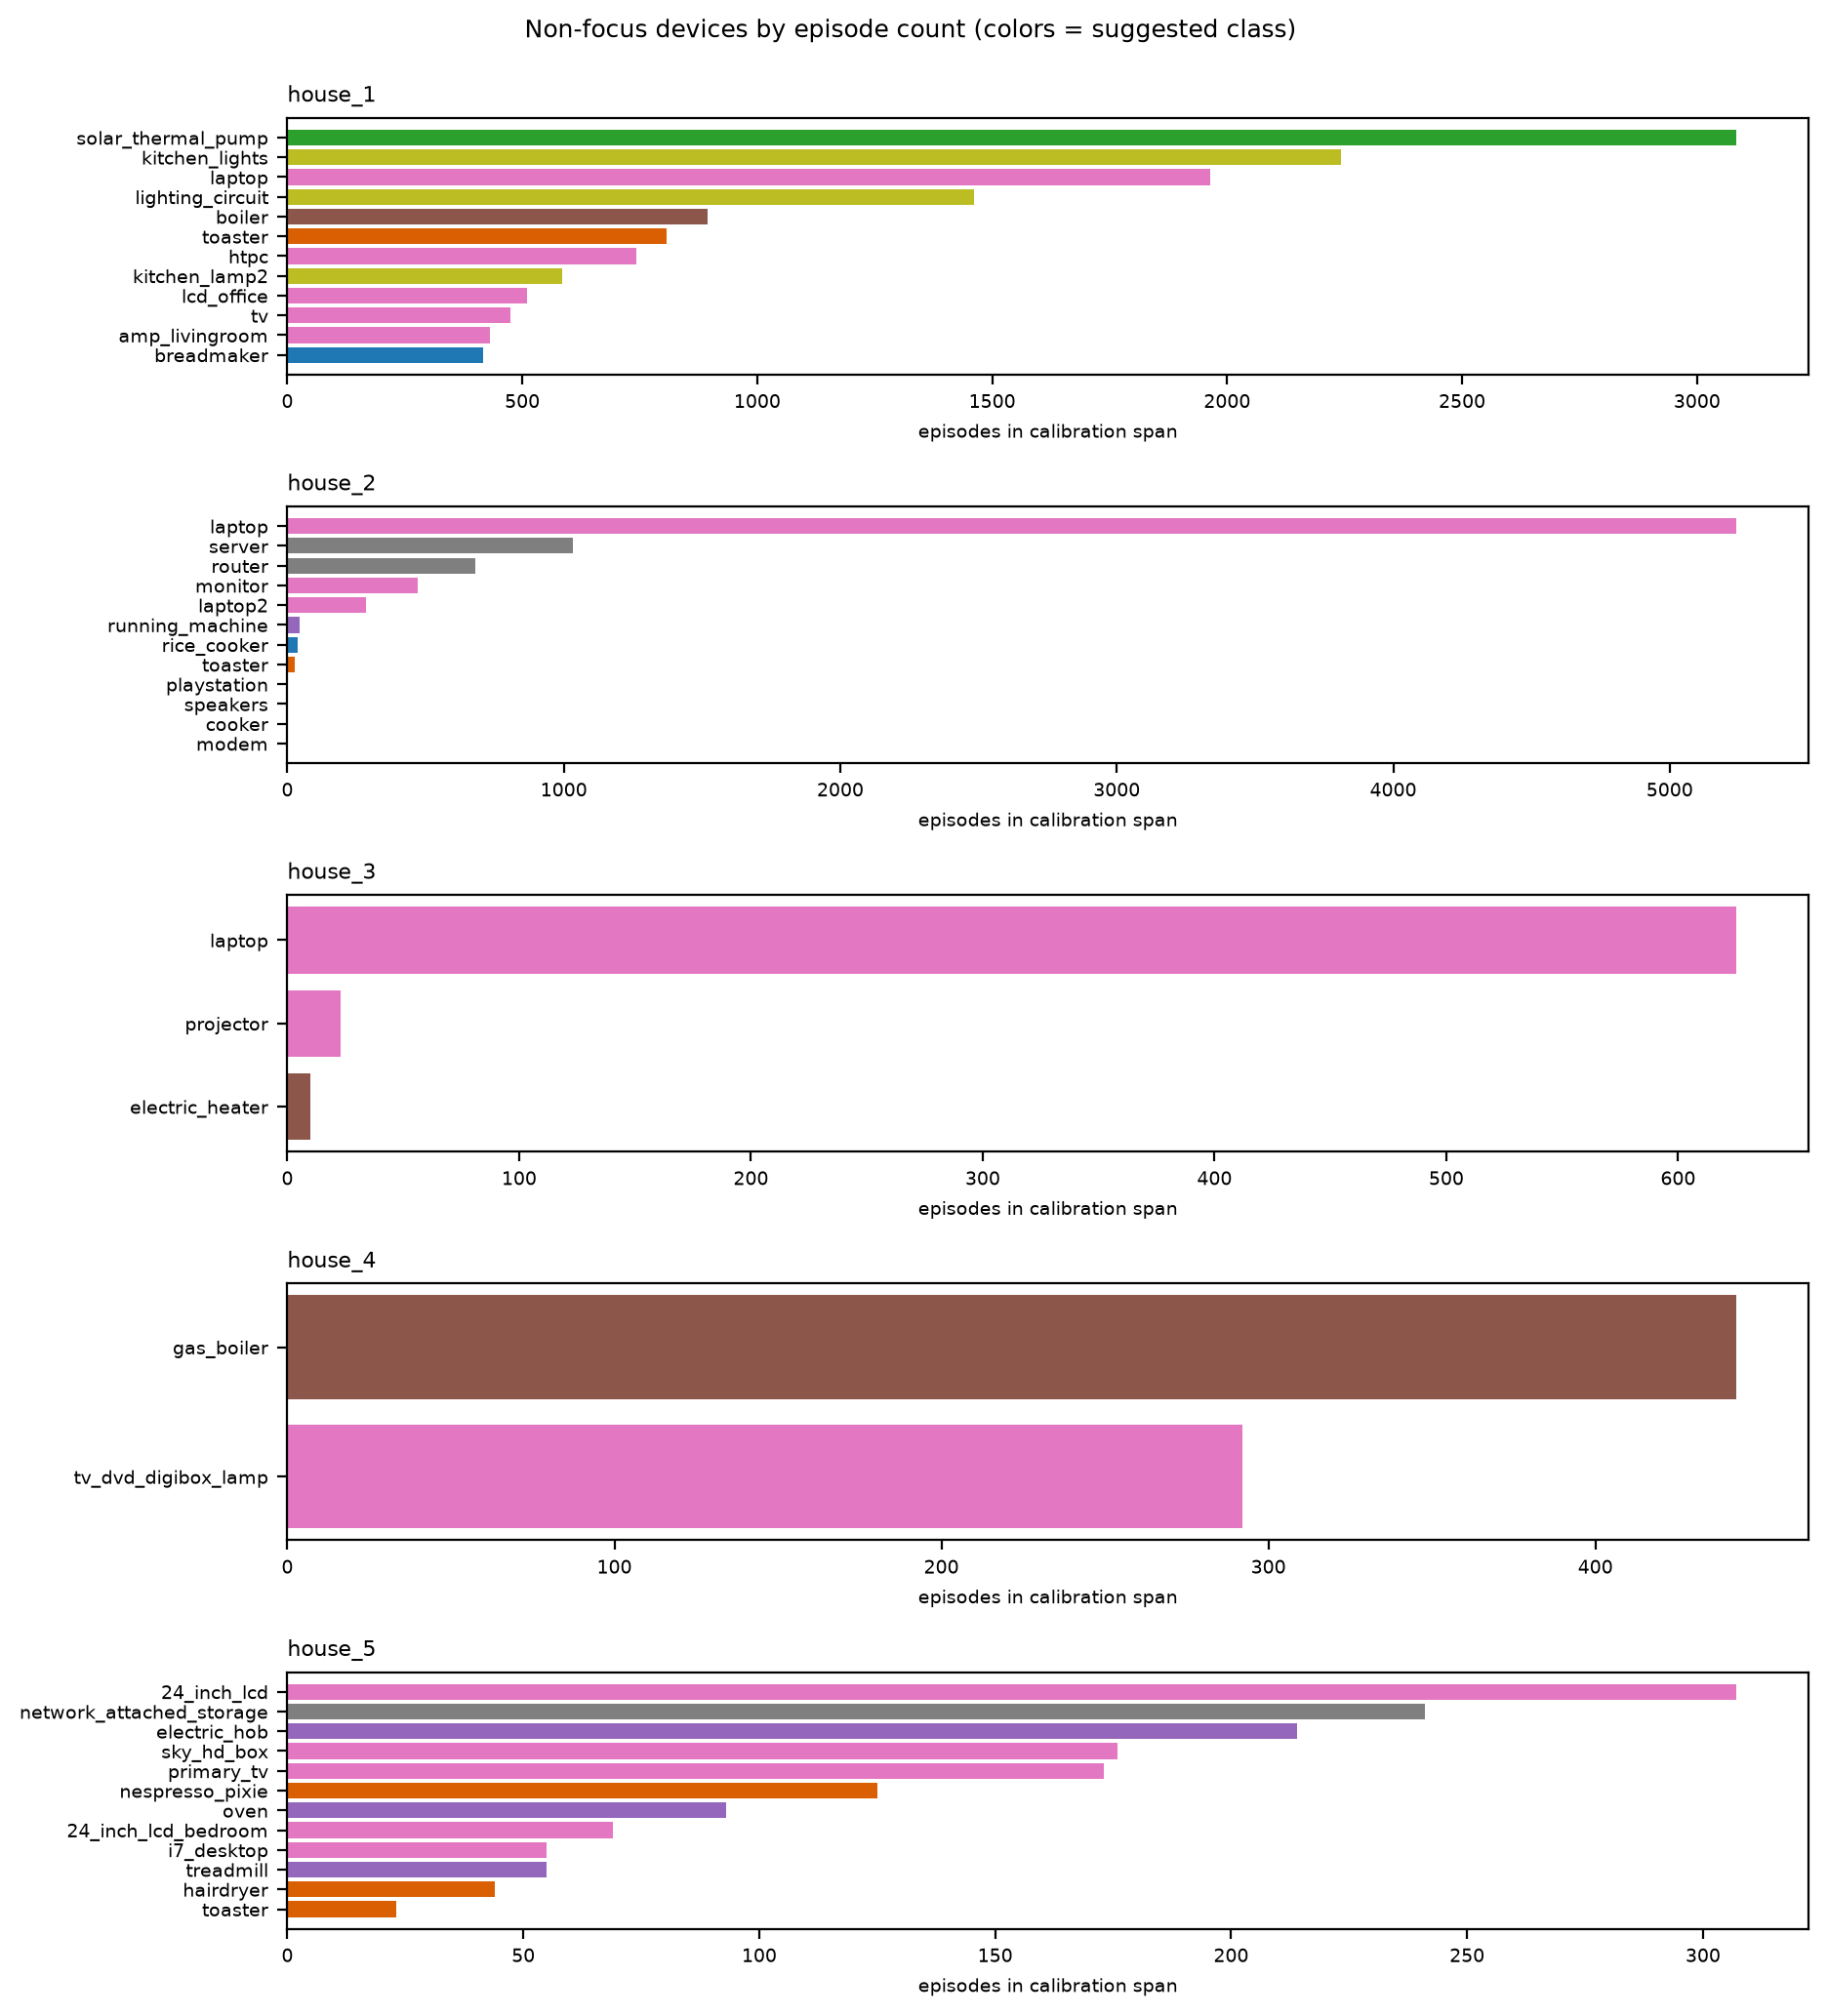

In [ ]:
# --- Per-house episodic ranking (fig) ------------------------------------
# Top non-focus devices by pre-split episodes: who is episodic at all?
_nf = profiles_df[~profiles_df["in_focus"]]
fig_rank, _axes = plt.subplots(5, 1, figsize=(9.5, 2.1 * 5))
for _ax, _h in zip(_axes, cfg["houses"]):
    _g = (
        _nf[_nf["house"] == _h]
        .sort_values("n_cycles_cal", ascending=False)
        .head(12)
        .iloc[::-1]
    )
    _colors = [cls_color.get(c, "#333333") for c in _g["class"]]
    _ax.barh(_g["device"], _g["n_cycles_cal"], color=_colors)
    _ax.set_title(_h, fontsize=8, loc="left")
    _ax.tick_params(labelsize=7)
    _ax.set_xlabel("episodes in calibration span", fontsize=7)
fig_rank.suptitle("Non-focus devices by episode count (colors = suggested class)", fontsize=9)
fig_rank.tight_layout(rect=(0, 0, 1, 0.99))
fig_rank  # noqa: B018  (render figure as cell output)

In [ ]:
# --- Curation candidate selection (computation) --------------------------
_nf = profiles_df[~profiles_df["in_focus"]].copy()
_nf["dwell_s"], _nf["merge_s"] = zip(
    *_nf["class"].map(lambda c: cfg["cand_rule"].get(c, (30.0, 60.0)))
)
cand_df = _nf[
    _nf["class"].isin(cfg["cand_rule"])
    & (_nf["n_cycles_cal"] >= cfg["cand_min_cal"])
].sort_values(["house", "n_cycles_cal"], ascending=[True, False])
skipped_df = _nf[
    _nf["class"].isin(cfg["cand_rule"])
    & (_nf["n_cycles_cal"] < cfg["cand_min_cal"])
].sort_values("n_cycles_cal", ascending=False)
_cand_rows = [
    [
        r["house"].replace("house_", "h"),
        r["device"],
        str(r["class"]),
        f"{r['thr_used_w']:.0f}",
        f"{r['dwell_s']:.0f}/{r['merge_s']:.0f}",
        f"{r['n_cycles_cal']:,}",
        f"{r['dur_p50_min']:.1f}",
        f"{r['energy_p50_wh']:.0f}",
    ]
    for r in cand_df.to_dict("records")
]
_skip_rows = [
    [r["house"].replace("house_", "h"), r["device"], str(r["class"]), f"{r['n_cycles_cal']:,}"]
    for r in skipped_df.to_dict("records")
]
mo.md(
    "## Extended-curation candidates\n\n"
    "Episodic non-focus devices with at least "
    f"{cfg['cand_min_cal']} pre-split episodes - each gets the 03 "
    "review-sheet treatment (whole-house strip under the submeter "
    "trace, top candidates by energy, hand-picked marks):\n\n"
    + bl.md_table(
        [
            "house",
            "device",
            "class",
            "thr (W)",
            "dwell/merge (s)",
            "episodes (cal)",
            "dur p50 (min)",
            "energy p50 (Wh)",
        ],
        _cand_rows,
    )
    + "\n\nEpisodic devices **below** the curation floor (too few "
    "pre-split episodes for 20 marks; recorded, not curated):\n\n"
    + bl.md_table(["house", "device", "class", "episodes (cal)"], _skip_rows)
)

## Extended-curation candidates

Episodic non-focus devices with at least 20 pre-split episodes - each gets the 03 review-sheet treatment (whole-house strip under the submeter trace, top candidates by energy, hand-picked marks):

| house | device | class | thr (W) | dwell/merge (s) | episodes (cal) | dur p50 (min) | energy p50 (Wh) |
|---|---|---|---|---|---|---|---|
| h1 | toaster | burst | 20 | 30/60 | 808 | 3.1 | 83 |
| h1 | breadmaker | program | 20 | 600/600 | 417 | 2.1 | 4 |
| h1 | gas_oven | manual | 20 | 30/300 | 216 | 22.9 | 18 |
| h1 | hoover | manual | 20 | 30/300 | 149 | 4.6 | 129 |
| h1 | hair_dryer | burst | 20 | 30/60 | 133 | 1.6 | 29 |
| h1 | straighteners | burst | 20 | 30/60 | 79 | 6.2 | 15 |
| h2 | running_machine | manual | 20 | 30/300 | 43 | 16.4 | 80 |
| h2 | rice_cooker | program | 20 | 600/600 | 38 | 28.3 | 140 |
| h2 | toaster | burst | 20 | 30/60 | 25 | 1.7 | 28 |
| h5 | electric_hob | manual | 20 | 30/300 | 214 | 5.0 | 38 |
| h5 | nespresso_pixie | burst | 20 | 30/60 | 125 | 2.0 | 22 |
| h5 | oven | manual | 20 | 30/300 | 93 | 26.5 | 673 |
| h5 | treadmill | manual | 20 | 30/300 | 55 | 16.9 | 128 |
| h5 | hairdryer | burst | 20 | 30/60 | 44 | 4.7 | 82 |
| h5 | toaster | burst | 20 | 30/60 | 23 | 2.0 | 39 |

Episodic devices **below** the curation floor (too few pre-split episodes for 20 marks; recorded, not curated):

| house | device | class | episodes (cal) |
|---|---|---|---|
| h1 | iron | manual | 18 |
| h5 | vacuum_cleaner | manual | 15 |
| h1 | soldering_iron | manual | 8 |
| h5 | steam_iron | manual | 7 |
| h1 | coffee_machine | program | 6 |
| h2 | cooker | manual | 1 |

In [ ]:
# --- Loaders + figure helpers (computation, 03 vocabulary) ---------------
_cache = {}

def load_chan(house, name):
    key = (house, name)
    if key not in _cache:
        _cache[key] = bl.load_series(bl.gold_file(cfg["dataset"], house, name))
    return _cache[key]

def split_us_of(house):
    return int(splits_df.loc[splits_df["house"] == house, "split_us"].iloc[0])

def busy_day(house, dev, thr):
    df = load_chan(house, dev)
    ts = df["ts_us"].to_numpy(np.int64)
    w = df["w"].to_numpy(float)
    days = (ts // 86_400_000_000).astype(np.int64)
    on_min = {}
    for d in np.unique(days):
        sel = days == d
        on_min[int(d)] = float(np.sum(w[sel] > thr) * 6.0 / 60.0)
    ranked = sorted(on_min, key=on_min.get, reverse=True)
    active = [d for d in ranked if on_min[d] > 0]
    return active[0], on_min

def overlay_fig(house, dev, day, thr, dwell, merge):
    """Strips: mains, submeter, candidate-rule spans (03 pattern)."""
    lo, hi = day * 86_400_000_000, (day + 1) * 86_400_000_000
    m = load_chan(house, "mains")
    m_ts = m["ts_us"].to_numpy(np.int64)
    m_w = m["w"].to_numpy(float)
    s = load_chan(house, dev)
    s_ts = s["ts_us"].to_numpy(np.int64)
    s_w = s["w"].to_numpy(float)
    fig, axes = plt.subplots(3, 1, figsize=(11, 5.2), sharex=True)
    i0, i1 = np.searchsorted(m_ts, lo), np.searchsorted(m_ts, hi)
    axes[0].plot((m_ts[i0:i1] - lo) / 3.6e9, m_w[i0:i1], color="#222222", lw=0.7)
    axes[0].set_ylabel("mains (W)")
    axes[0].set_title(
        f"{house} {dev}: busiest day ({pd.to_datetime(lo, unit='us'):%Y-%m-%d} UTC)",
        fontsize=9,
        loc="left",
    )
    j0, j1 = np.searchsorted(s_ts, lo), np.searchsorted(s_ts, hi)
    axes[1].plot((s_ts[j0:j1] - lo) / 3.6e9, s_w[j0:j1], color="#d95f02", lw=0.8)
    axes[1].set_ylabel(f"{dev} sub (W)", fontsize=8)
    ep = bl.build_episodes(s, thr, dwell, merge, 60.0)
    sel = ep[(ep["t_on_us"] < hi) & (ep["t_off_us"] > lo)]
    for r in sel.itertuples():
        axes[2].axvspan(
            (r.t_on_us - lo) / 3.6e9,
            (r.t_off_us - lo) / 3.6e9,
            color="#2ca02c",
            alpha=0.35,
            lw=0,
        )
    axes[2].set_ylabel(f"rule {dwell:.0f}/{merge:.0f}s @ {thr:.0f} W", fontsize=7)
    axes[2].set_yticks([])
    axes[2].set_xlabel("hours since 00:00 UTC")
    axes[0].set_xlim(0, 24)
    fig.tight_layout()
    return fig

def sheet_fig(house, dev, thr, dwell, merge):
    """Review sheet: top calibration-span candidates by energy (03 pattern)."""
    s = load_chan(house, dev)
    ep = bl.build_episodes(s, thr, dwell, merge, 60.0)
    cal = ep[ep["t_on_us"] < split_us_of(house)]
    cal = (
        cal.sort_values("energy_wh", ascending=False)
        .head(cfg["sheet_top"])
        .reset_index(drop=True)
    )
    m = load_chan(house, "mains")
    m_ts = m["ts_us"].to_numpy(np.int64)
    m_w = m["w"].to_numpy(float)
    s_ts = s["ts_us"].to_numpy(np.int64)
    s_w = s["w"].to_numpy(float)
    n = len(cal)
    fig, axes = plt.subplots(n, 1, figsize=(11, 0.9 * n + 1.0))
    if n == 1:
        axes = [axes]
    pad = int(cfg["sheet_pad_s"] * 1_000_000)
    for ax, (idx, r) in zip(axes, cal.iterrows()):
        a, b = int(r["t_on_us"]) - pad, int(r["t_off_us"]) + pad
        i0, i1 = np.searchsorted(m_ts, a), np.searchsorted(m_ts, b)
        j0, j1 = np.searchsorted(s_ts, a), np.searchsorted(s_ts, b)
        ax.plot((m_ts[i0:i1] - a) / 3.6e9, m_w[i0:i1], color="#222222", lw=0.8)
        ax.plot((s_ts[j0:j1] - a) / 3.6e9, s_w[j0:j1], color="#d95f02", lw=0.9)
        ax.axvspan(
            (int(r["t_on_us"]) - a) / 3.6e9,
            (int(r["t_off_us"]) - a) / 3.6e9,
            color="#2ca02c",
            alpha=0.2,
            lw=0,
        )
        ax.set_ylabel(f"#{idx + 1}", fontsize=7)
        ax.set_yticks([])
        ax.set_xticks([])
    fig.suptitle(
        f"{house} {dev}: calibration-span candidates @ {thr:.0f} W "
        f"(dwell {dwell:.0f}s / merge {merge:.0f}s), top {n} by energy "
        "(black = whole-house power, orange = submeter, green = rule span)",
        fontsize=8,
    )
    fig.tight_layout(rect=(0, 0, 1, 0.997))
    info = [
        {
            "row": i + 1,
            "t_on_us": int(r["t_on_us"]),
            "t_off_us": int(r["t_off_us"]),
            "dur_min": float(r["dur_s"]) / 60.0,
            "wh": float(r["energy_wh"]),
        }
        for i, (_, r) in enumerate(cal.iterrows())
    ]
    return fig, info

In [ ]:
# --- Per-candidate figures + row tables (computation) --------------------
# One busiest-day overlay (in-context) + one review sheet per candidate.
cand_figs = {}
for _r in cand_df.to_dict("records"):
    _h, _dev = _r["house"], _r["device"]
    _thr = float(_r["thr_used_w"])
    _dwell, _merge = float(_r["dwell_s"]), float(_r["merge_s"])
    _day, _ = busy_day(_h, _dev, _thr)
    _ov = overlay_fig(_h, _dev, _day, _thr, _dwell, _merge)
    _sf, _info = sheet_fig(_h, _dev, _thr, _dwell, _merge)
    _info_df = pd.DataFrame(_info)
    _info_df["start (UTC)"] = pd.to_datetime(
        _info_df["t_on_us"], unit="us", utc=True
    ).dt.strftime("%m-%d %H:%M")
    _info_df = _info_df.drop(columns=["t_on_us", "t_off_us"])
    _info_df["dur_min"] = _info_df["dur_min"].round(1)
    _info_df["wh"] = _info_df["wh"].round(0)
    cand_figs[f"{_h}|{_dev}"] = {
        "overlay": _ov,
        "sheet": _sf,
        "info": _info_df,
        "rec": _r,
    }

/tmp/marimo_31/__marimo__cell_Hstk_.py:35: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(3, 1, figsize=(11, 5.2), sharex=True)


In [ ]:
# presentation: per-candidate review packs in accordions
_items = {}
for _key, _pack in cand_figs.items():
    _h, _dev = _key.split("|")
    _rec = _pack["rec"]
    _title = f"{_h.replace('house_', 'h')} - {_dev} ({_rec['class']}, {_rec['n_cycles_cal']} cal episodes)"
    _items[_title] = mo.vstack(
        [
            mo.md(
                "Busiest day + candidate-rule spans, then the review "
                "sheet. Row ids below feed the curation decision."
            ),
            _pack["overlay"],
            _pack["sheet"],
            mo.md(
                "Candidate rows:\n\n"
                + bl.md_table(
                    ["row", "start (UTC)", "dur (min)", "energy (Wh)"],
                    _pack["info"][["row", "start (UTC)", "dur_min", "wh"]].values.tolist(),
                )
            ),
        ]
    )
mo.accordion(_items)

<marimo-callout-output data-html='"\u003cspan class=\"markdown prose dark:prose-invert contents\"\u003e\u003cspan class=\"paragraph\"\u003e\u003cspan class=\"text-error\"\u003e\u003cstrong\u003eYour output is too large\u003c/strong\u003e\u003c/span\u003e\u003c/span\u003e\n\u003cspan class=\"paragraph\"\u003eYour output is too large for marimo to show. It has a size\nof 26505742 bytes. Did you output this object by accident?\u003c/span\u003e\n\u003cspan class=\"paragraph\"\u003eIf this limitation is a problem for you, you can configure\nthe max output size by adding (eg)\u003c/span\u003e\n\u003cdiv class=\"language-ini codehilite\"\u003e\u003cpre\u003e\u003cspan\u003e\u003c/span\u003e\u003ccode\u003e\u003cspan class=\"k\"\u003e[tool.marimo.runtime]\u003c/span\u003e\n\u003cspan class=\"na\"\u003eoutput_max_bytes\u003c/span\u003e\u003cspan class=\"w\"\u003e \u003c/span\u003e\u003cspan class=\"o\"\u003e=\u003c/span\u003e\u003cspan class=\"w\"\u003e \u003c/span\u003e\u003cspan class=\"s\"\u003e10_000_000\u003c/span\u003e\n\u003c/code\u003e\u003c/pre\u003e\u003c/div\u003e\n\u003cspan class=\"paragraph\"\u003eto your pyproject.toml, or with the environment variable\n\u003ccode\u003eMARIMO_OUTPUT_MAX_BYTES\u003c/code\u003e:\u003c/span\u003e\n\u003cdiv class=\"language-gdscript codehilite\"\u003e\u003cpre\u003e\u003cspan\u003e\u003c/span\u003e\u003ccode\u003e\u003cspan class=\"k\"\u003eexport\u003c/span\u003e\u003cspan class=\"w\"\u003e \u003c/span\u003e\u003cspan class=\"n\"\u003eMARIMO_OUTPUT_MAX_BYTES\u003c/span\u003e\u003cspan class=\"o\"\u003e=\u003c/span\u003e\u003cspan class=\"mi\"\u003e10\u003c/span\u003e\u003cspan class=\"n\"\u003e_000_000\u003c/span\u003e\n\u003c/code\u003e\u003c/pre\u003e\u003c/div\u003e\n\u003cspan class=\"paragraph\"\u003eIncreasing the max output size may cause performance issues.\nIf you run into problems, please reach out\nto us on \u003ca href=\"https://marimo.io/discord?ref=app\" rel=\"noopener noreferrer\" target=\"_blank\"\u003eDiscord\u003c/a\u003e or\n\u003ca href=\"https://github.com/marimo-team/marimo/issues\" rel=\"noopener noreferrer\" target=\"_blank\"\u003eGitHub\u003c/a\u003e.\u003c/span\u003e\u003c/span\u003e"' data-kind='"warn"'>

## Findings

**Coverage.** The metadata pass profiles all 103 UK-DALE gold channels:
13 keep their gold threshold, 4 use reviewed overrides, 84 fall back to
a generic 20 W threshold (30 s dwell / 60 s merge), 2 are excluded.
Class split: electronics 35, burst 16, lighting 15, manual 11, program
9, always_on 9, duty 5, heating 3. 19 devices carry the `in_focus`
flag: the 6 first-pass devices (washer, dishwasher, kettle, microwave,
fridge) plus the 13 second-pass episodic devices curated below.

**Curation outcome.** 13 devices x 20 marks = 260 `manual_review_v2`
spans appended to the manual store (device list + per-device guards in
`data/gold_annot/README.md`): h1 toaster/hoover/hair_dryer/straighteners,
h2 running_machine/rice_cooker/toaster, h5 electric_hob/nespresso_pixie/
oven/toaster/treadmill/hairdryer. Every kept span was audited
numerically and visually against mains + submeter. house_3 and house_4
contribute nothing: house_3 has only 34 kettle episodes and no other
episodic load; house_4\'s microwave channel yields 0 usable episodes
(mixed channel) and the house lacks the other episodic classes.

**Two devices fail the sheets - recorded so nobody retries them blind:**

- **house_1 gas_oven is igniter-only at the 20 W threshold.** Its
  episodes are glow-plug pulses (p50 23 min at ~46 W on-power), not
  cooking cycles; the real h1 cooking load is invisible to the electric
  submeter. house_5\'s oven, by contrast, is the genuine 2.1 kW
  resistive load and was curated normally.
- **house_1 breadmaker fails the program-class duty floor.** Under the
  program candidate rule (600 s dwell / 600 s merge) only 2 candidate
  rows pass in the calibration span: the generic-rule episodes fragment
  into short bursts (p50 2.1 min at ~558 W - knead/bake plateaus far
  below the 600 s floor). A program-class rule is the wrong shape for
  this device; it was left uncurated.

**Load contract.** Everything downstream reads the union via
`baseline_lib.gt_cycles(dataset, house)` - the 360 marks now cover 15
device-house pairs across 3 houses, all pre-split.